# Introduction to Q-Learning


---

In this Jupyter Notebook you will learn the basics of Q-Learning.


### Credits
- [Huggingface Deep Reinforcement Learning Course](https://huggingface.co/learn/deep-rl-course/unit0/introduction)
- [Gymnasium](https://gymnasium.farama.org/)

# Unit 2: Q-Learning with FrozenLake-v1 and Taxi-v3

In this notebook, **we'll code a Reinforcement Learning agent from scratch** to play FrozenLake  using Q-Learning.


<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/envs.gif" alt="Environments" width="50%"/>

###🎮 Environments:

- [FrozenLake-v1](https://gymnasium.farama.org/environments/toy_text/frozen_lake/)
- [Taxi-v3](https://gymnasium.farama.org/environments/toy_text/taxi/)

## A small recap of Q-Learning

*Q-Learning* **is the Reinforcement Learning algorithm that**:

- Trains *Q-Function*, an **action-value function** that encoded, in internal memory, by a *Q-table* **that contains all the state-action pair values.**

- Given a state and action, our Q-Function **will search the Q-table for the corresponding value.**

- In simpler terms: For a given state the Q-table tells us how good future states are that we might end up in when taking an action. The Q-value is a numerical number. Higher values represent preferrable states.
    
<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/Q-function-2.jpg" alt="Q function"  width="50%"/>

- When the training is done,**we have an optimal Q-Function, so an optimal Q-Table.**
    
- And if we **have an optimal Q-function**, we
have an optimal policy π, since we **know for, each state, the best action to take.**

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/link-value-policy.jpg" alt="Link value policy"  width="50%"/>


But, in the beginning (before training), our **Q-Table is useless since it gives wrong values for each state-action pair (most of the time we initialize the Q-Table to 0 values)**. But, as we’ll explore the environment and update our Q-Table it will give us better and better approximations

This is the Q-Learning pseudocode:

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/Q-learning-2.jpg" alt="Q-Learning" width="50%"/>


## Install dependencies and create a virtual display


In the notebook, we'll need to generate a replay video. To do so, with Colab, **we need to have a virtual screen to render the environment** (and thus record the frames).

Hence the following cell will install the libraries and create and run a virtual screen 🖥

We’ll install multiple ones:

- `gymnasium`: Contains the FrozenLake-v1 ⛄ and Taxi-v3 🚕 virtual environments.
- `numpy`: Used for handling our Q-table.

In [1]:
# Added to requirements.txt
# !sudo apt-get update -q
# !sudo apt-get install -y python3-opengl -q
# !apt install ffmpeg xvfb -q
# !uv pip install pyvirtualdisplay -q
# !uv pip install gymnasium pygame numpy imageio imageio_ffmpeg pyglet==1.5.1 tqdm -q

To make sure the new installed libraries are used, **sometimes it's required to restart the notebook runtime**. The next cell will force the **runtime to crash, so you'll need to connect again and run the code starting from here**. Thanks to this trick, **we will be able to run our virtual screen.**

In [2]:
# import os
# os.kill(os.getpid(), 9)

## Import the packages


In addition to the installed libraries, we also use:

- `random`: To generate random numbers
- `imageio`: To generate a replay video.

In [3]:
import numpy as np
import gymnasium as gym
import random
import imageio
import os
import tqdm

from tqdm.notebook import tqdm

from IPython.display import Image

We're now ready to code our Q-Learning algorithm 🔥

# Part 1: Frozen Lake (non slippery version)

A good habit when you start to use an environment is to check its documentation

https://gymnasium.farama.org/environments/toy_text/frozen_lake/

---

We're going to train our Q-Learning agent **to navigate from the starting state (S) to the goal state (G) by walking only on frozen tiles (F) and avoid holes (H)**.

We can have two sizes of environment:

- `map_name="4x4"`: a 4x4 grid version
- `map_name="8x8"`: a 8x8 grid version


The environment has two modes:

- `is_slippery=False`: The agent always moves **in the intended direction** due to the non-slippery nature of the frozen lake (deterministic).
- `is_slippery=True`: The agent **may not always move in the intended direction** due to the slippery nature of the frozen lake (stochastic).

For now let's keep it simple with the 4x4 map and non-slippery.
We add a parameter called `render_mode` that specifies how the environment should be visualised. In our case because we **want to record a video of the environment at the end, we need to set `render_mode` to rgb_array**.

As [explained in the documentation](https://gymnasium.farama.org/api/env/#gymnasium.Env.render) `rgb_array`: Return a single frame representing the current state of the environment. A frame is a np.ndarray with shape (x, y, 3) representing RGB values for an x-by-y pixel image.

`desc` can be `None`.

In [4]:
# Create the FrozenLake-v1 environment using 4x4 map and non-slippery version and render_mode="rgb_array"

import gymnasium as gym
env = gym.make('FrozenLake-v1',
        desc=None,               # custom map (list of strings)
        map_name='4x4',          # '4x4' or '8x8'
        is_slippery=False,        # adds stochastic movement
        success_rate=1/3,        # probability of intended direction
        reward_schedule=(1,0,0), # (goal, hole, frozen)
        render_mode="rgb_array"
)



### Let's see what the Environment looks like:


In [5]:
# We create our environment with gym.make("<name_of_the_environment>")- `is_slippery=False`: The agent always moves in the intended direction due to the non-slippery nature of the frozen lake (deterministic).
print("_____OBSERVATION SPACE_____ \n")
print("Observation Space", env.observation_space)
print("Sample observation", env.observation_space.sample()) # Get a random observation

_____OBSERVATION SPACE_____ 

Observation Space Discrete(16)
Sample observation 11


We see with `Observation Space Shape Discrete(16)` that the observation is an integer representing the **agent’s current position as current_row * ncols + current_col (where both the row and col start at 0)**.

For example, the goal position in the 4x4 map can be calculated as follows: 3 * 4 + 3 = 15. The number of possible observations is dependent on the size of the map. **For example, the 4x4 map has 16 possible observations.**


For instance, this is what state = 0 looks like:

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/notebooks/unit2/frozenlake.png" alt="FrozenLake" width="20%">

In [6]:
print("\n _____ACTION SPACE_____ \n")
print("Action Space Shape", env.action_space.n)
print("Action Space Sample", env.action_space.sample()) # Take a random action


 _____ACTION SPACE_____ 

Action Space Shape 4
Action Space Sample 2


The action space (the set of possible actions the agent can take) is discrete with 4 actions available 🎮:
- 0: GO LEFT
- 1: GO DOWN
- 2: GO RIGHT
- 3: GO UP

Reward function 💰:
- Reach goal: +1
- Reach hole: 0
- Reach frozen: 0

## Create and Initialize the Q-table 🗄️

(👀 Step 1 of the pseudocode)

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/Q-learning-2.jpg" alt="Q-Learning" width="50%"/>


It's time to initialize our Q-table! To know how many rows (states) and columns (actions) to use, we need to know the action and observation space. We already know their values from before, but we'll want to obtain them programmatically so that our algorithm generalizes for different environments. Gym provides us a way to do that: `env.action_space.n` and `env.observation_space.n`

In [7]:
state_space =   env.observation_space.n
print("There are ", state_space, " possible states")

action_space =  env.action_space.n
print("There are ", action_space, " possible actions")

There are  16  possible states
There are  4  possible actions


In [8]:
# Let's create our Qtable of size (state_space, action_space) and initialized each values at 0 using np.zeros. np.zeros needs a tuple (a,b)
def initialize_q_table(state_space, action_space):
  Qtable = np.zeros((state_space, action_space))
  return Qtable

In [9]:
Qtable_frozenlake = initialize_q_table(state_space, action_space)

## Define the greedy policy 🤖


Remember we have two policies since Q-Learning is an **off-policy** algorithm. This means we're using a **different policy for acting and updating the value function**.

- Epsilon-greedy policy (acting policy)
- Greedy-policy (updating policy)

The greedy policy will also be the final policy we'll have when the Q-learning agent completes training. The greedy policy is used to select an action using the Q-table.

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/off-on-4.jpg" alt="Q-Learning" width="50%"/>

In [10]:
def greedy_policy(Qtable, state):
  # Exploitation: take the action with the highest state, action value
  # (argmax could be useful here)
  action = np.argmax(Qtable[state])

  return action

## Define the epsilon-greedy policy 🤖

Epsilon-greedy is the training policy that handles the exploration/exploitation trade-off.

The idea with epsilon-greedy:

- With *probability 1 - ɛ* : **we do exploitation** (i.e. our agent selects the action with the highest state-action pair value).

- With *probability ɛ*: we do **exploration** (trying a random action).

As the training continues, we progressively **reduce the epsilon value since we will need less and less exploration and more exploitation.**

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/Q-learning-4.jpg" alt="Q-Learning" width="50%"/>


In [11]:
random_num = np.random.rand()
print(random_num)

0.5707069741979115


In [12]:
def epsilon_greedy_policy(Qtable, state, epsilon):
  # Randomly generate a number between 0 and 1
  random_num = np.random.rand()

  # if random_num > greater than epsilon --> exploitation
  #     Take the action with the highest value given a state
  #     remember to reuse code and functions
  if random_num > epsilon:
    action = greedy_policy(Qtable, state)
  
  # else --> exploration
  else:
    # Take a random action
    action = np.random.randint(Qtable.shape[1])

  return action

## Define the hyperparameters ⚙️

The exploration related hyperparamters are some of the most important ones.

- Hyperparameters are variables that are not learned or improved during training. They have to be defined before we run our training experiment and they can heavily influence the quality of our results.
- We need to make sure that our agent **explores enough of the state space** to learn a good value approximation. So, in the beginning the agent should be explorative and over time it should prefer using its acquired knowledge to best achieve its goals. To do that, we need to have progressive decay of the epsilon.
- If you decrease epsilon too fast (too high decay_rate), **you take the risk that your agent will be stuck**, since your agent didn't explore enough of the state space, did not experience enough ways to solve the problem and hence can't solve the problem.

In [13]:
# Training parameters
n_training_episodes = 10000  # Total training episodes
learning_rate = 0.7          # Learning rate

# Evaluation parameters
n_eval_episodes = 100        # Total number of test episodes

# Environment parameters
env_id = "FrozenLake-v1"     # Name of the environment
max_steps = 99               # Max steps per episode
gamma = 0.95                 # Discounting rate
eval_seed = []               # The evaluation seed of the environment

# Exploration parameters
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.05            # Minimum exploration probability
decay_rate = 0.0005            # Exponential decay rate for exploration prob

## Create the training loop method

<img src="https://huggingface.co/datasets/huggingface-deep-rl-course/course-images/resolve/main/en/unit3/Q-learning-2.jpg" alt="Q-Learning" width="50%"/>

The training loop goes like this:

```
For episode in the total of training episodes:

Reduce epsilon (since we need less and less exploration)
Reset the environment

  For step in max timesteps:    
    Choose the action At using epsilon greedy policy
    Take the action (a) and observe the outcome state(s') and reward (r)
    Update the Q-value Q(s,a) using Bellman equation Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    If done, finish the episode
    Our next state is the new state
```

**Task:** Fill in the code where it is missing below!

In [14]:

def train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable, gamma, learning_rate):
  for episode in tqdm(range(n_training_episodes)):
    # Reduce epsilon (because we need less and less exploration)
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)
    # Reset the environment
    state, info = env.reset()
    step = 0
    terminated = False
    truncated = False


    for step in range(max_steps):
      # Choose the action At using epsilon greedy policy
      action = epsilon_greedy_policy(Qtable, state, epsilon)

      # Take action At and observe Rt+1 and St+1
      #     Take the action (a) and observe the outcome state(s') and reward (r)
      #     Note: The action is performed by the environment
      new_state, reward, terminated, truncated, info = env.step(action)

      # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
      # YOUR CODE HERE
      Q_curr = Qtable[state][action]
      Q_next_max = np.max(Qtable[new_state])

      Qtable[state][action] = Q_curr + learning_rate * (reward + gamma * Q_next_max - Q_curr)

      # If terminated or truncated finish the episode
      if terminated or truncated:
        break

      # Our next state is the new state
      state = new_state
  return Qtable

## Train the Q-Learning agent 🏃

In [15]:
Qtable_frozenlake = train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_frozenlake, gamma, learning_rate)

  0%|          | 0/10000 [00:00<?, ?it/s]

## Let's see what our Q-Learning table looks like now 👀

In [16]:
Qtable_frozenlake

array([[0.73509189, 0.77378094, 0.77378094, 0.73509189],
       [0.73509189, 0.        , 0.81450625, 0.77378094],
       [0.77378094, 0.857375  , 0.77378094, 0.81450625],
       [0.81450625, 0.        , 0.77378094, 0.77378094],
       [0.77378094, 0.81450625, 0.        , 0.73509189],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.        , 0.81450625],
       [0.        , 0.        , 0.        , 0.        ],
       [0.81450625, 0.        , 0.857375  , 0.77378094],
       [0.81450625, 0.9025    , 0.9025    , 0.        ],
       [0.857375  , 0.95      , 0.        , 0.857375  ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.9025    , 0.95      , 0.857375  ],
       [0.9025    , 0.95      , 1.        , 0.9025    ],
       [0.        , 0.        , 0.        , 0.        ]])

## The evaluation method

- We defined the evaluation method that we're going to use to test our Q-Learning agent.

In [17]:
################################
#  DO NOT CHANGE THIS FUNCTION #
################################

def evaluate_agent(env, max_steps, n_eval_episodes, Q, seed):
  """
  Evaluate the agent for ``n_eval_episodes`` episodes and returns average reward and std of reward.
  :param env: The evaluation environment
  :param max_steps: Maximum number of steps per episode
  :param n_eval_episodes: Number of episode to evaluate the agent
  :param Q: The Q-table
  :param seed: The evaluation seed array (for taxi-v3)
  """
  episode_rewards = []
  for episode in tqdm(range(n_eval_episodes)):
    if seed:
      state, info = env.reset(seed=seed[episode])
    else:
      state, info = env.reset()
    step = 0
    truncated = False
    terminated = False
    total_rewards_ep = 0

    for step in range(max_steps):
      # Take the action (index) that have the maximum expected future reward given that state
      action = greedy_policy(Q, state)
      new_state, reward, terminated, truncated, info = env.step(action)
      total_rewards_ep += reward

      if terminated or truncated:
        break
      state = new_state
    episode_rewards.append(total_rewards_ep)
  mean_reward = np.mean(episode_rewards)
  std_reward = np.std(episode_rewards)

  return mean_reward, std_reward

## Evaluate our Q-Learning agent

- Usually, you should have a mean reward of 1.0
- The **environment is relatively easy** since the state space is really small (16). What you can try to do is [to replace it with the slippery version](https://gymnasium.farama.org/environments/toy_text/frozen_lake/), which introduces stochasticity, making the environment more complex.

In [18]:
# Evaluate our Agent
#       env: the environment to test in.
#       max_steps: max steps per episode.
#       n_eval_episodes: how many test episodes to run.
#       Q: the Q-table you want to evaluate.
#       seed: optional list of seeds for repeatable starts.




mean_reward, std_reward = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_frozenlake, eval_seed)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Mean_reward=1.00 +/- 0.00


## Visualize our Results

In order to visualize our agent's policy in action use the function `record_video` below.

Run the cells to see the results in a GIF.

In [19]:
def record_video(env, Qtable, out_directory, fps=1):
  """
  Generate a replay video of the agent
  :param env
  :param Qtable: Qtable of our agent
  :param out_directory
  :param fps: how many frame per seconds (with taxi-v3 and frozenlake-v1 we use 1)
  """
  images = []
  terminated = False
  truncated = False
  state, info = env.reset(seed=random.randint(0,500))
  img = env.render()
  images.append(img)
  while not terminated or truncated:
    # Take the action (index) that have the maximum expected future reward given that state
    action = np.argmax(Qtable[state][:])
    state, reward, terminated, truncated, info = env.step(action) # We directly put next_state = state for recording logic
    img = env.render()
    images.append(img)
  imageio.mimsave(out_directory, [np.array(img) for i, img in enumerate(images)], fps=fps)

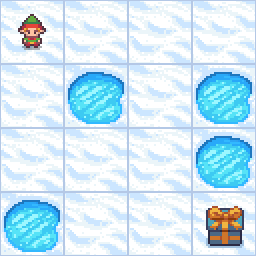

In [20]:
record_video(env, Qtable_frozenlake, '/tmp/result_frozen.gif')
Image(open('/tmp/result_frozen.gif','rb').read())

Congrats 🥳 you've just implemented from scratch and trained your first Reinforcement Learning agent.
However, FrozenLake-v1 no_slippery is very simple environment, let's try a harder one 🔥.

# Part 2: Taxi-v3

## Create and understand the [Taxi-v3](https://gymnasium.farama.org/environments/toy_text/taxi/) environment


In [25]:
env = gym.make(
    "Taxi-v4", 
    render_mode="rgb_array"
)

There are **500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger** (including the case when the passenger is in the taxi), and **4 destination locations.**


In [26]:
state_space = env.observation_space.n
print("There are ", state_space, " possible states")

There are  500  possible states


In [27]:
action_space = env.action_space.n
print("There are ", action_space, " possible actions")

There are  6  possible actions


The action space (the set of possible actions the agent can take) is discrete with **6 actions available 🎮**:

- 0: move south
- 1: move north
- 2: move east
- 3: move west
- 4: pickup passenger
- 5: drop off passenger

Reward function 💰:

- -1 per step unless other reward is triggered.
- +20 delivering passenger.
- -10 executing “pickup” and “drop-off” actions illegally.

In [28]:
# Create our Q table with state_size rows and action_size columns (500x6)
Qtable_taxi = initialize_q_table(state_space, action_space)
print(Qtable_taxi)
print("Q-table shape: ", Qtable_taxi .shape)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
Q-table shape:  (500, 6)


## Define the hyperparameters

DO NOT MODIFY EVAL_SEED: the eval_seed array **allows us to evaluate your agent with the same taxi starting positions for every classmate**

In [29]:
# Training parameters
n_training_episodes = 25000   # Total training episodes
learning_rate = 0.2           # Learning rate

# Evaluation parameters
n_eval_episodes = 100        # Total number of test episodes

# DO NOT MODIFY EVAL_SEED
eval_seed = [16,54,165,177,191,191,120,80,149,178,48,38,6,125,174,73,50,172,100,148,146,6,25,40,68,148,49,167,9,97,164,176,61,7,54,55,
 161,131,184,51,170,12,120,113,95,126,51,98,36,135,54,82,45,95,89,59,95,124,9,113,58,85,51,134,121,169,105,21,30,11,50,65,12,43,82,145,152,97,106,55,31,85,38,
 112,102,168,123,97,21,83,158,26,80,63,5,81,32,11,28,148] # Evaluation seed, this ensures that all classmates agents are trained on the same taxi starting position
                                                          # Each seed has a specific starting state

# Environment parameters
env_id = "Taxi-v3"           # Name of the environment, do not modify
max_steps = 99               # Max steps per episode
gamma = 0.5                 # Discounting rate

# Exploration parameters
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.05           # Minimum exploration probability
decay_rate = 0.005            # Exponential decay rate for exploration prob


## Train our Q-Learning agent

In [33]:
# Train the Q-learning agent to obtain a policy π.

Qtable_taxi = train(
    n_training_episodes, 
    min_epsilon, max_epsilon, 
    decay_rate, 
    env, 
    max_steps, 
    Qtable_taxi, 
    gamma, 
    learning_rate
)

print(Qtable_taxi)

  0%|          | 0/25000 [00:00<?, ?it/s]

[[  0.           0.           0.           0.           0.
    0.        ]
 [ -1.98839862  -1.97787462  -1.98817835  -1.97828343  -1.95703125
  -10.91723573]
 [ -1.82454842  -1.65911182  -1.82628132  -1.65710008  -1.3125
  -10.58663427]
 ...
 [ -1.38219346  -0.62759282  -1.34788281  -1.4645213   -4.9448
   -6.89189288]
 [ -1.90433584  -1.90566329  -1.91239922  -1.90364886  -8.86748451
   -6.2507666 ]
 [ -0.32528     -0.36        -0.2          9.          -3.91536
   -5.08650775]]


Evaluate your learned policy π.


In [35]:
mean_reward, std_reward = evaluate_agent(env, max_steps, n_eval_episodes, Qtable_taxi, eval_seed)
print(f"Mean_reward={mean_reward:.2f} +/- {std_reward:.2f}")

  0%|          | 0/100 [00:00<?, ?it/s]

Mean_reward=7.56 +/- 2.71


Visualize the agent controlling a taxi.
Different scenarios are shown for each execution of this cell. But the agent always follows the same policy defined by the Q-table.

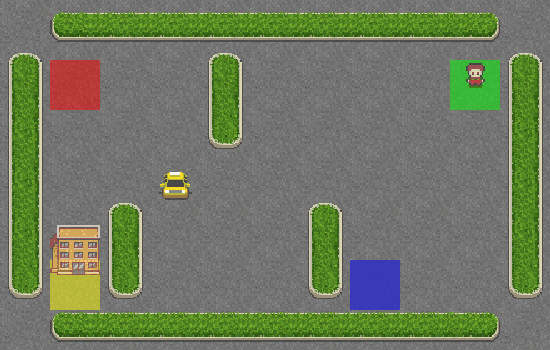

In [36]:
record_video(env, Qtable_taxi, '/tmp/result_taxi.gif')
Image(open('/tmp/result_taxi.gif','rb').read())